<a href="https://colab.research.google.com/github/sandrarajp/E-commerce-data-science-business/blob/main/Eccomerce_Data_Science_%26_BS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# List the contents of your Google Drive
# You can modify the path to navigate to specific folders
drive_path = '/content/drive/MyDrive/Bases de Datos 2026'

if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"'{drive_path}' not found. Make sure your Google Drive is mounted correctly and the path is correct.")

'/content/drive/MyDrive/Bases de Datos 2026' not found. Make sure your Google Drive is mounted correctly and the path is correct.


In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
csv_file_path = os.path.join(drive_path, 'online_retail_II.csv')
df = pd.read_csv("/content/drive/MyDrive/Online Retail.csv")
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [9]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)

df.columns


Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

**Data Cleaning:**

In [10]:
# Convert invoice date to datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')

# Detect correct price column safely
price_col = 'price' if 'price' in df.columns else 'unitprice'

# Drop rows missing key fields
df = df.dropna(subset=['invoicedate', 'quantity', price_col, 'country'])

# Define return logic using the CORRECT invoice column
df['is_return'] = (
    df['invoiceno'].astype(str).str.startswith('C') |
    (df['quantity'] < 0)
)
# Absolute quantity for consistent aggregation
df['abs_quantity'] = df['quantity'].abs()


/tmp/ipykernel_2623/2841246352.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')


**Product** **return** **risk** **key** **questions**:

* Which products have the highest return rates as a share of units sold?

* Do high-return products share characteristics such as price range or category?

* Does a Pareto pattern hold — do a small number of products account for most returns?



**Customer** **return** **risk** **key** **questions**:

* What share of customers accounts for the majority of return volume?

* Do high-return customers show distinct purchasing behavior, such as higher order frequency or larger basket sizes?

* Is there a correlation between purchase frequency and return rate?



**Geographic** and **temporal** **key** **questions**:

* Are return rates significantly higher in specific countries?

* Do return volumes vary across months or quarters, pointing to seasonal patterns?



**Core Metrics:**

In [11]:
# Revenue (can be negative for returns)
df['revenue'] = df['quantity'] * df['unitprice']

# Month & year for time analysis
df['year_month'] = df['invoicedate'].dt.to_period('M')

# Clean dataset (optional but recommended)
df_clean = df[df['quantity'] > 0]  # sales only
df_returns = df[df['is_return']]   # returns only

 **Geographical analysis**: Are return rates higher in specific countries?

In [12]:
country_summary = df.groupby('country').agg(
    total_qty=('abs_quantity', 'sum'),
    return_qty=('is_return', 'sum')
)

country_summary['return_rate'] = country_summary['return_qty'] / country_summary['total_qty']
country_summary = country_summary.sort_values(by='return_rate', ascending=False)

display(country_summary.head(10))

,total_qty,return_qty,return_rate
country,,,
USA,3882,112,0.028851
Malta,996,15,0.015060
Saudi Arabia,85,1,0.011765
Czech Republic,750,5,0.006667
Italy,8225,45,0.005471
Germany,121078,453,0.003741
Poland,3715,11,0.002961
Bahrain,368,1,0.002717
European Community,501,1,0.001996


**Visual:**

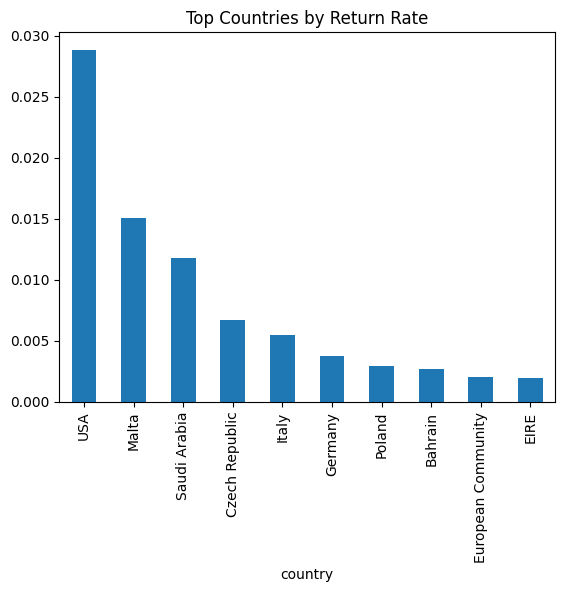

In [13]:
country_summary.head(10)['return_rate'].plot(kind='bar')
plt.title("Top Countries by Return Rate")
plt.show()

**Time / Seasonality Analysis:** Do returns vary across months?

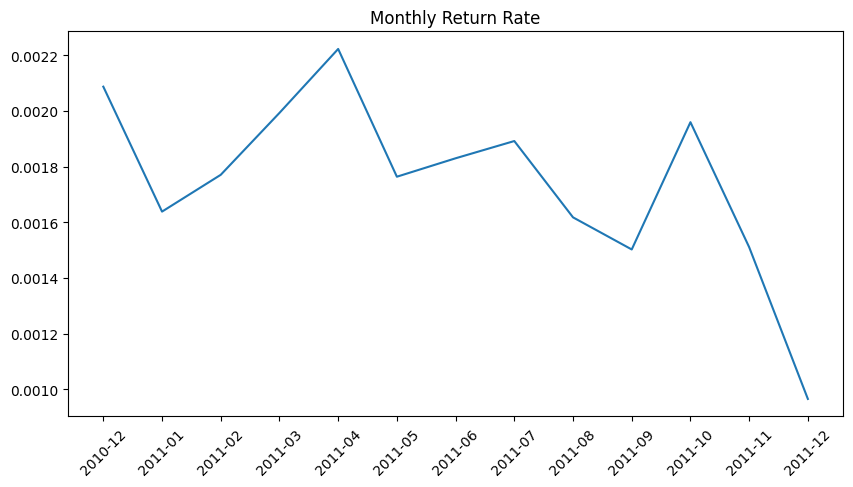

In [14]:
monthly = df.groupby('year_month').agg(
    total=('abs_quantity', 'sum'),
    returns=('is_return', 'sum')
)

monthly['return_rate'] = monthly['returns'] / monthly['total']
monthly = monthly.reset_index()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly['year_month'].astype(str), monthly['return_rate'])
plt.xticks(rotation=45)
plt.title("Monthly Return Rate")
plt.show()

**Product Analysis:** Which products have highest return rates?

In [15]:
product_summary = df.groupby('stockcode').agg(
    total_qty=('abs_quantity', 'sum'),
    return_qty=('is_return', 'sum'),
    avg_price=('unitprice', 'mean')
)

product_summary['return_rate'] = product_summary['return_qty'] / product_summary['total_qty']

# Remove products with low volume (avoid noise)
product_summary = product_summary[product_summary['total_qty'] > 50]

product_summary = product_summary.sort_values(by='return_rate', ascending=False)

product_summary.head(10)

,total_qty,return_qty,avg_price,return_rate
stockcode,,,,
S,63,61,50.404603,0.968254
22655,81,9,147.457447,0.111111
23462,132,13,20.143390,0.098485
21275,56,4,16.766471,0.071429
23458,56,4,14.950000,0.071429
23487,89,6,10.315600,0.067416
84631,76,5,7.765667,0.065789
22826,62,4,115.388889,0.064516
D,1194,77,72.484545,0.064489


**Pareto Analysis:**

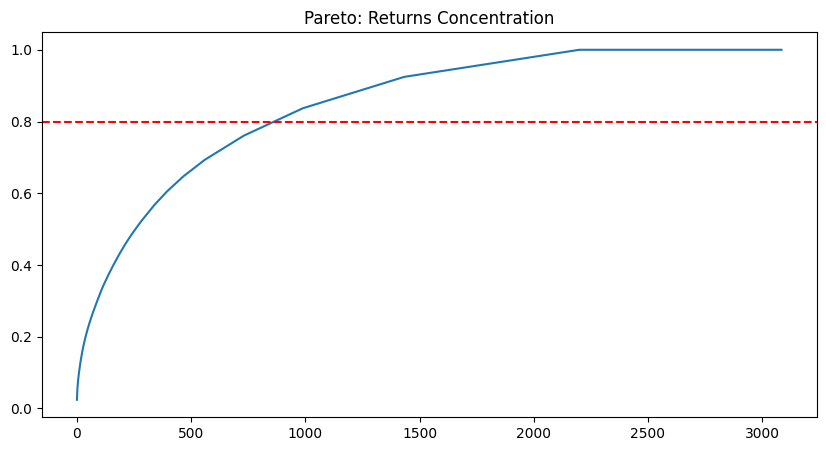

In [16]:
# Sort by return quantity
pareto = product_summary.sort_values(by='return_qty', ascending=False)

# Cumulative %
pareto['cum_pct'] = pareto['return_qty'].cumsum() / pareto['return_qty'].sum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(pareto['cum_pct'].values)
plt.axhline(0.8, color='red', linestyle='--')
plt.title("Pareto: Returns Concentration")
plt.show()


**Customer Analysis:** Who are the high-return customers?

In [19]:
customer_summary = df.groupby('customerid').agg(
    total_orders=('invoiceno', 'nunique'),
    total_qty=('abs_quantity', 'sum'),
    return_qty=('is_return', 'sum')
)

customer_summary['return_rate'] = customer_summary['return_qty'] / customer_summary['total_qty']

customer_summary = customer_summary.sort_values(by='return_qty', ascending=False)

customer_summary.head(10)


,total_orders,total_qty,return_qty,return_rate
customerid,,,,
14911.0,248,83850,226,0.002695
17841.0,169,23277,136,0.005843
17511.0,46,66086,113,0.001710
15311.0,118,38668,112,0.002896
12607.0,2,2456,101,0.041124
14410.0,15,853,93,0.109027
13798.0,63,24382,90,0.003691
14606.0,128,6470,82,0.012674
13113.0,40,3506,79,0.022533


**Correlation:**

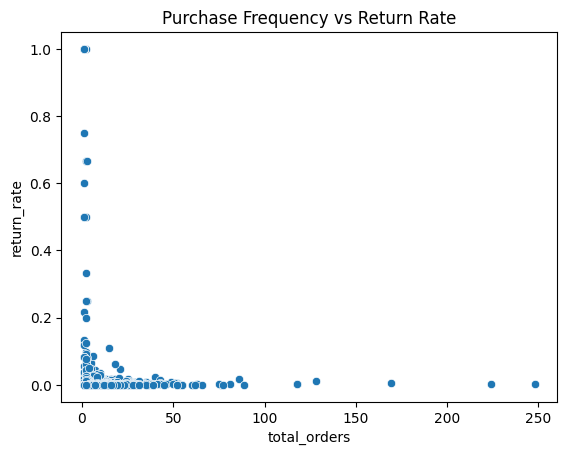

In [20]:
sns.scatterplot(
    data=customer_summary,
    x='total_orders',
    y='return_rate'
)
plt.title("Purchase Frequency vs Return Rate")
plt.show()


**Behavior Analysis:**

<Axes: xlabel='is_return', ylabel='basket_size'>

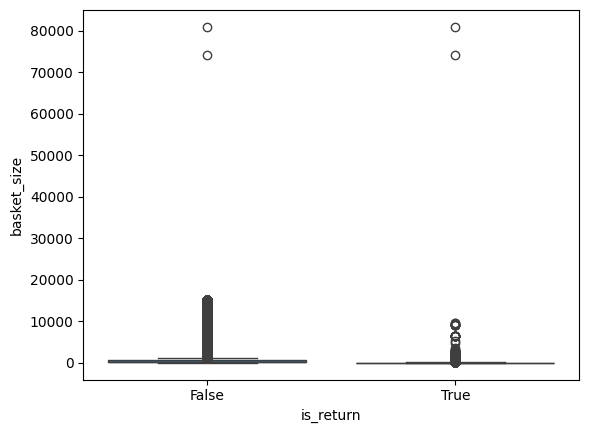

In [22]:
basket_size = df.groupby('invoiceno')['abs_quantity'].sum()

basket_df = df.merge(basket_size.rename('basket_size'), on='invoiceno')

sns.boxplot(x='is_return', y='basket_size', data=basket_df)
